# Task 3: Customer Churn Prediction

## Research Purpose

This notebook studies bank customer churn from a retention analyst's point of view. The goal is to understand which customer characteristics are associated with leaving the bank, then build a model that can rank churn risk in a practical way.

The target variable is `Exited`: `1` means the customer left, and `0` means the customer stayed. Since churners are the minority class, I do not rely on accuracy alone. The analysis uses descriptive analytics, statistical tests, VIF/correlation checks, class-aware model evaluation, and a threshold review that connects the model to retention action.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette=["#1D3557", "#E63946", "#2A9D8F", "#F4A261"],
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
    },
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## Dataset Loading and First Look

In [2]:
local_path = DATA_DIR / "Churn_Modelling.csv"
if not local_path.exists():
    raise FileNotFoundError(f"Expected local dataset at {local_path}.")

raw_df = pd.read_csv(local_path)

print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]:,}")
raw_df.head()

Rows: 10,000
Columns: 14


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Research note:** The dataset includes profile attributes, account attributes, and the churn outcome. `RowNumber`, `CustomerId`, and `Surname` are identifiers rather than predictors; keeping them in the model would add noise or leakage-style memorization without creating useful retention insight.

In [3]:
quality_report = pd.DataFrame(
    {
        "dtype": raw_df.dtypes.astype(str),
        "missing_values": raw_df.isna().sum(),
        "missing_rate": raw_df.isna().mean(),
        "unique_values": raw_df.nunique(dropna=True),
    }
).sort_values(["missing_values", "unique_values"], ascending=[False, False])

display(quality_report)
display(raw_df["Exited"].value_counts().rename("churn_count"))
display(raw_df["Exited"].value_counts(normalize=True).rename("churn_rate").round(3))

,dtype,missing_values,missing_rate,unique_values
RowNumber,int64,0,0.0,10000
CustomerId,int64,0,0.0,10000
EstimatedSalary,float64,0,0.0,9999
Balance,float64,0,0.0,6382
Surname,object,0,0.0,2932
CreditScore,int64,0,0.0,460
Age,int64,0,0.0,70
Tenure,int64,0,0.0,11
NumOfProducts,int64,0,0.0,4
Geography,object,0,0.0,3


Exited
0    7963
1    2037
Name: churn_count, dtype: int64

Exited
0    0.796
1    0.204
Name: churn_rate, dtype: float64

## Cleaning and Feature Setup

In [4]:
df = raw_df.drop(columns=["RowNumber", "CustomerId", "Surname"], errors="ignore").copy()

target = "Exited"
numeric_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
]
categorical_features = ["Geography", "Gender"]

df["BalanceToSalary"] = df["Balance"] / df["EstimatedSalary"].replace(0, np.nan)
df["BalanceToSalary"] = df["BalanceToSalary"].replace([np.inf, -np.inf], np.nan)
df["IsZeroBalance"] = (df["Balance"] == 0).astype(int)
df["AgeBand"] = pd.cut(
    df["Age"],
    bins=[17, 30, 40, 50, 60, 95],
    labels=["18-30", "31-40", "41-50", "51-60", "61+"],
)

engineered_numeric = numeric_features + ["BalanceToSalary", "IsZeroBalance"]
model_categorical = categorical_features + ["AgeBand"]

X = df[engineered_numeric + model_categorical]
y = df[target]

display(X.head())
print(f"Observed churn rate: {y.mean():.3f}")

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceToSalary,IsZeroBalance,Geography,Gender,AgeBand
0,619,42,2,0.00,1,1,1,101348.88,0.000000,1,France,Female,41-50
1,608,41,1,83807.86,1,0,1,112542.58,0.744677,0,Spain,Female,41-50
2,502,42,8,159660.80,3,1,0,113931.57,1.401375,0,France,Female,41-50
3,699,39,1,0.00,2,0,0,93826.63,0.000000,1,France,Female,31-40
4,850,43,2,125510.82,1,1,1,79084.10,1.587055,0,Spain,Female,41-50


Observed churn rate: 0.204


## Descriptive Statistical Analytics

In [5]:
churn_summary = (
    df.groupby(target)[engineered_numeric]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

churn_summary

CreditScore                          Age                      Tenure  \
             count    mean median     std count   mean median    std  count   
Exited                                                                        
0             7963  651.85  653.0   95.65  7963  37.41   36.0  10.13   7963   
1             2037  645.35  646.0  100.32  2037  44.84   45.0   9.76   2037   

              ... EstimatedSalary           BalanceToSalary               \
        mean  ...          median       std           count  mean median   
Exited        ...                                                          
0       5.03  ...        99645.04  57405.59            7963  2.48   0.70   
1       4.93  ...       102460.84  57912.42            2037  9.35   0.89   

               IsZeroBalance                     
           std         count  mean median   std  
Exited                                           
0        14.80          7963  0.39    0.0  0.49  
1       238.22          2037  0.25    0.0  0.43  

[2 rows x 40 columns]

In [6]:
segment_summary = (
    df.groupby(["Geography", "Gender", "AgeBand"], observed=False)[target]
    .agg(customers="count", churn_rate="mean")
    .reset_index()
    .query("customers >= 50")
    .sort_values("churn_rate", ascending=False)
)

segment_summary.head(12).round(3)

,Geography,Gender,AgeBand,customers,churn_rate
13,Germany,Female,51-60,129,0.736
18,Germany,Male,51-60,114,0.649
3,France,Female,51-60,171,0.643
23,Spain,Female,51-60,91,0.549
12,Germany,Female,41-50,330,0.524
14,Germany,Female,61+,53,0.509
17,Germany,Male,41-50,348,0.454
8,France,Male,51-60,196,0.423
28,Spain,Male,51-60,96,0.375
22,Spain,Female,41-50,271,0.336


**Research note:** The headline churn rate is only the starting point. Segment-level churn is more useful for action because retention teams do not contact an average customer; they contact groups with specific profiles, balances, product counts, and activity patterns.

## Exploratory Visual Analytics

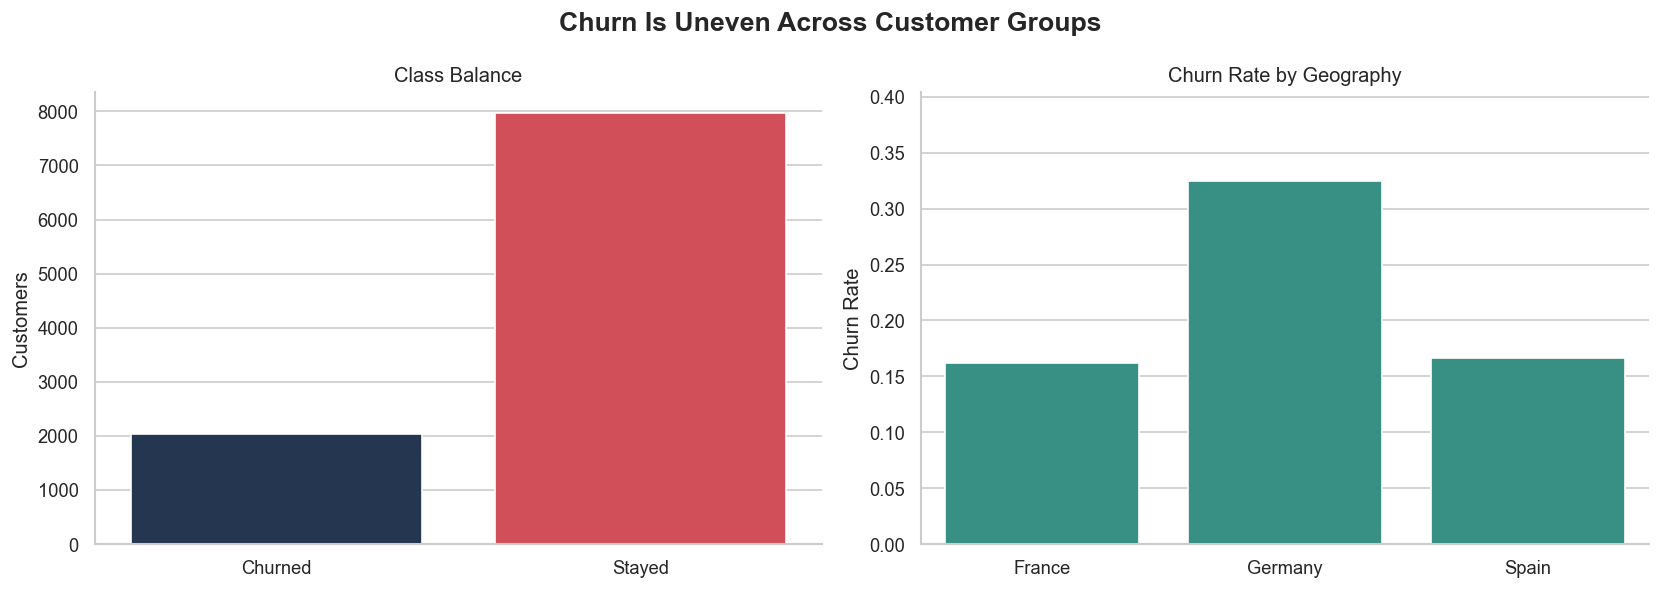

In [7]:
plot_df = df.copy()
plot_df["Churn status"] = plot_df[target].map({0: "Stayed", 1: "Churned"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=plot_df, x="Churn status", ax=axes[0], palette=["#1D3557", "#E63946"])
axes[0].set_title("Class Balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Customers")

sns.barplot(
    data=plot_df.groupby("Geography", as_index=False)[target].mean(),
    x="Geography",
    y=target,
    ax=axes[1],
    color="#2A9D8F",
)
axes[1].set_title("Churn Rate by Geography")
axes[1].set_xlabel("")
axes[1].set_ylabel("Churn Rate")
axes[1].set_ylim(0, plot_df.groupby("Geography")[target].mean().max() + 0.08)

fig.suptitle("Churn Is Uneven Across Customer Groups", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task3_class_balance_geography.png", dpi=180, bbox_inches="tight")
plt.show()

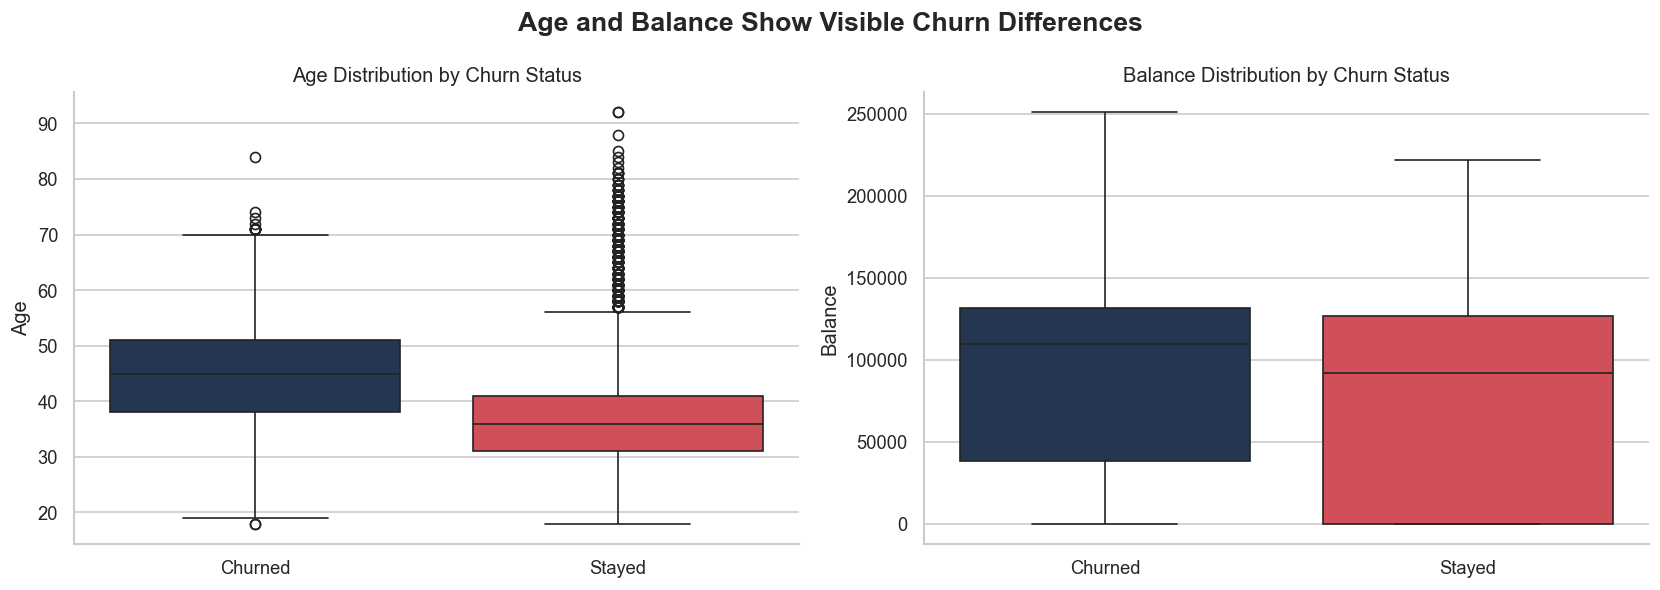

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=plot_df, x="Churn status", y="Age", ax=axes[0], palette=["#1D3557", "#E63946"])
axes[0].set_title("Age Distribution by Churn Status")
axes[0].set_xlabel("")
axes[0].set_ylabel("Age")

sns.boxplot(data=plot_df, x="Churn status", y="Balance", ax=axes[1], palette=["#1D3557", "#E63946"])
axes[1].set_title("Balance Distribution by Churn Status")
axes[1].set_xlabel("")
axes[1].set_ylabel("Balance")

fig.suptitle("Age and Balance Show Visible Churn Differences", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task3_age_balance_boxplots.png", dpi=180, bbox_inches="tight")
plt.show()

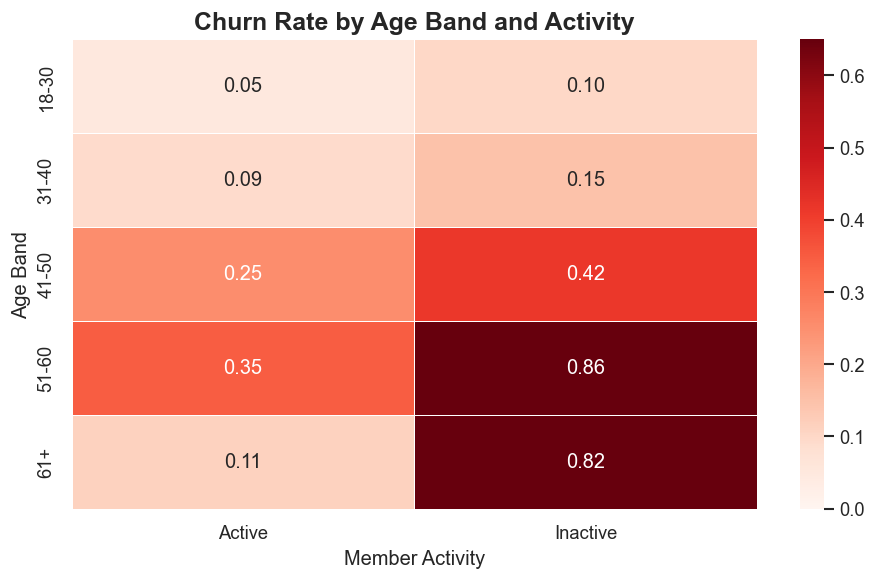

IsActiveMember,Active,Inactive
AgeBand,,
18-30,0.051,0.101
31-40,0.092,0.149
41-50,0.254,0.416
51-60,0.347,0.857
61+,0.112,0.820


In [9]:
rate_table = (
    df.groupby(["AgeBand", "IsActiveMember"], observed=False)[target]
    .mean()
    .reset_index()
)
rate_table["IsActiveMember"] = rate_table["IsActiveMember"].map({0: "Inactive", 1: "Active"})
pivot_rates = rate_table.pivot(index="AgeBand", columns="IsActiveMember", values=target)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_rates, annot=True, fmt=".2f", cmap="Reds", linewidths=0.5, vmin=0, vmax=0.65)
plt.title("Churn Rate by Age Band and Activity", fontsize=15, fontweight="bold")
plt.xlabel("Member Activity")
plt.ylabel("Age Band")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task3_age_activity_churn_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

pivot_rates.round(3)

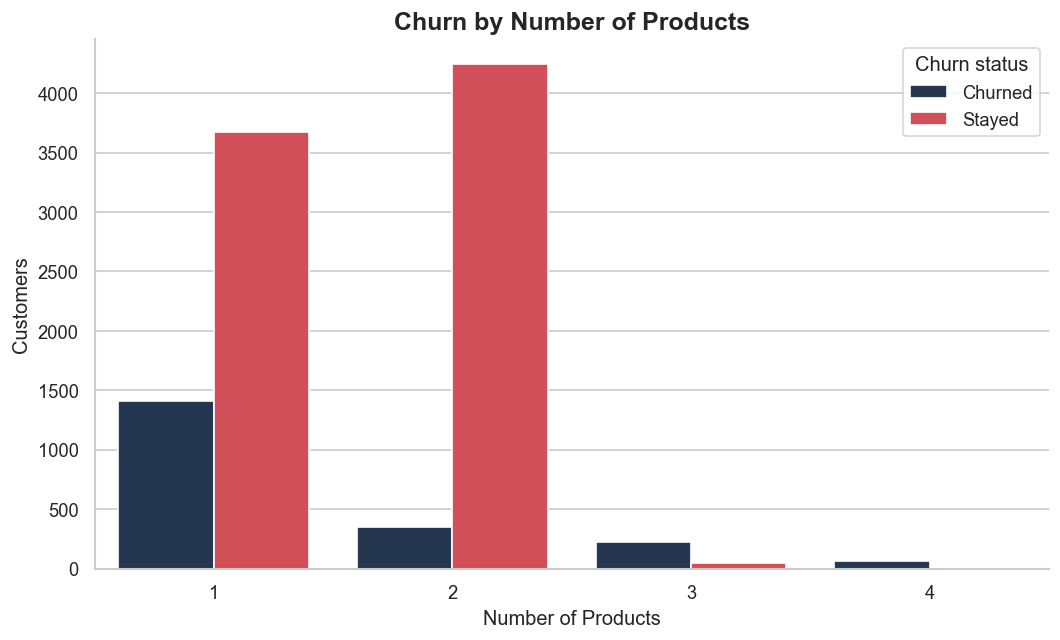

In [10]:
plt.figure(figsize=(9, 5.5))
sns.countplot(
    data=plot_df,
    x="NumOfProducts",
    hue="Churn status",
    palette=["#1D3557", "#E63946"],
)
plt.title("Churn by Number of Products", fontsize=15, fontweight="bold")
plt.xlabel("Number of Products")
plt.ylabel("Customers")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task3_products_churn_count.png", dpi=180, bbox_inches="tight")
plt.show()

## Statistical Tests and Meaningful Drivers

In [11]:
test_rows = []

for col in ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary", "BalanceToSalary"]:
    churned = df.loc[df[target] == 1, col].dropna()
    stayed = df.loc[df[target] == 0, col].dropna()
    stat, p_value = stats.mannwhitneyu(churned, stayed, alternative="two-sided")
    test_rows.append(
        {
            "feature": col,
            "test": "Mann-Whitney U",
            "churned_median": churned.median(),
            "stayed_median": stayed.median(),
            "p_value": p_value,
        }
    )

for col in ["Geography", "Gender", "HasCrCard", "IsActiveMember", "AgeBand", "IsZeroBalance"]:
    contingency = pd.crosstab(df[col], df[target])
    chi2, p_value, _, _ = stats.chi2_contingency(contingency)
    test_rows.append(
        {
            "feature": col,
            "test": "Chi-square",
            "churned_median": np.nan,
            "stayed_median": np.nan,
            "p_value": p_value,
        }
    )

test_table = pd.DataFrame(test_rows).sort_values("p_value")
test_table["p_value"] = test_table["p_value"].map(lambda value: f"{value:.3e}")
test_table.round(2)

,feature,test,churned_median,stayed_median,p_value
11,AgeBand,Chi-square,NaN,NaN,5.702e-278
1,Age,Mann-Whitney U,45.00,36.00,3.210e-230
7,Geography,Chi-square,NaN,NaN,3.830e-66
10,IsActiveMember,Chi-square,NaN,NaN,8.786e-55
4,NumOfProducts,Mann-Whitney U,1.00,2.00,5.275e-36
12,IsZeroBalance,Chi-square,NaN,NaN,2.753e-34
3,Balance,Mann-Whitney U,109349.29,92072.68,1.116e-28
8,Gender,Chi-square,NaN,NaN,2.248e-26
6,BalanceToSalary,Mann-Whitney U,0.89,0.70,2.650e-25
0,CreditScore,Mann-Whitney U,646.00,653.00,1.987e-02


**Research note:** Not every available field deserves the same attention. The stronger churn story comes from age, activity, balance, product count, and geography. Estimated salary is useful to keep in the dataset, but it is not automatically a strong churn explanation just because it is numeric.

## Correlation and Multicollinearity Review

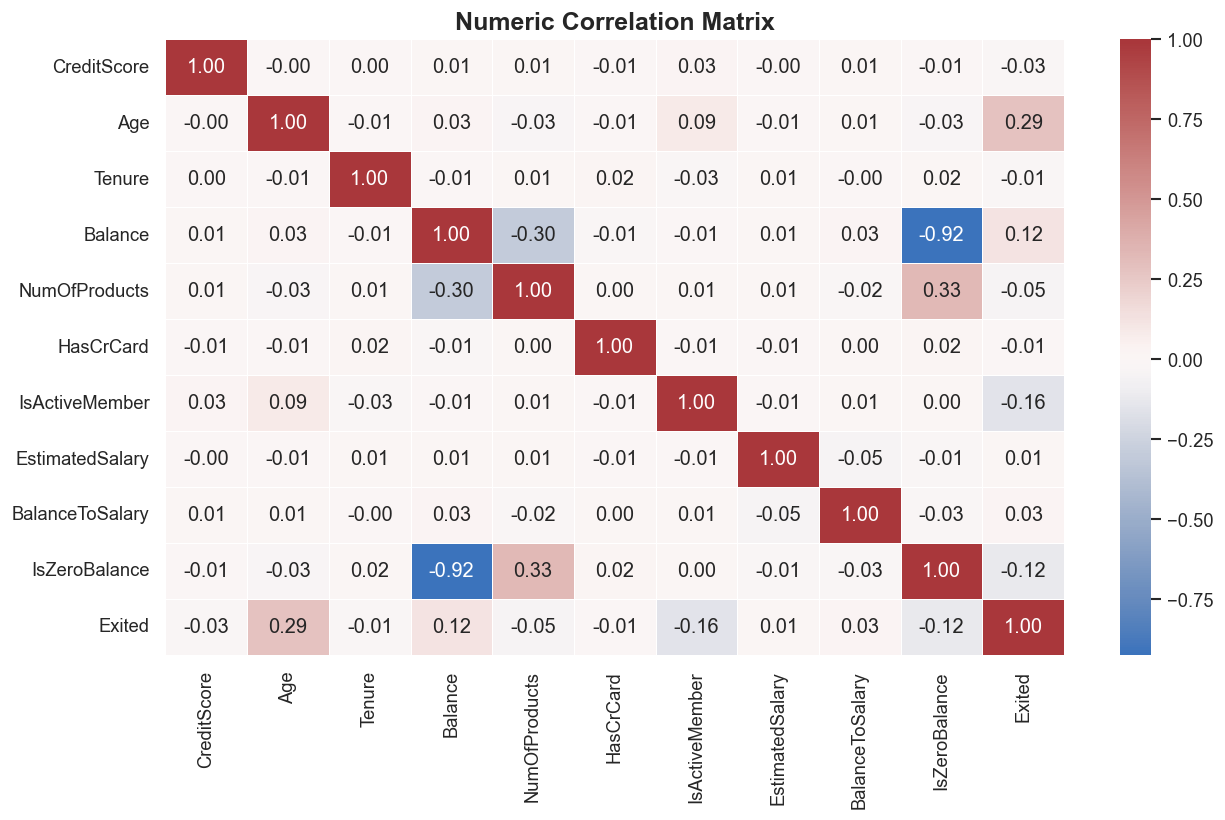

Age                0.285
Balance            0.119
BalanceToSalary    0.026
EstimatedSalary    0.012
HasCrCard         -0.007
Tenure            -0.014
CreditScore       -0.027
NumOfProducts     -0.048
IsZeroBalance     -0.122
IsActiveMember    -0.156
Name: Exited, dtype: float64

In [12]:
corr_cols = engineered_numeric + [target]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=0.5)
plt.title("Numeric Correlation Matrix", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task3_correlation_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

corr[target].drop(target).sort_values(ascending=False).round(3)

In [13]:
def calculate_vif(frame, columns):
    numeric = frame[columns].replace([np.inf, -np.inf], np.nan).dropna()
    numeric = numeric.loc[:, numeric.nunique() > 1]
    return (
        pd.DataFrame(
            {
                "feature": numeric.columns,
                "vif": [
                    variance_inflation_factor(numeric.values, i)
                    for i in range(numeric.shape[1])
                ],
            }
        )
        .sort_values("vif", ascending=False)
        .reset_index(drop=True)
    )

vif_table = calculate_vif(df, engineered_numeric)
vif_table.round(2)

,feature,vif
0,CreditScore,25.77
1,Age,12.75
2,Balance,12.64
3,IsZeroBalance,8.48
4,NumOfProducts,8.37
5,EstimatedSalary,3.92
6,Tenure,3.90
7,HasCrCard,3.32
8,IsActiveMember,2.07
9,BalanceToSalary,1.00


**Research note:** VIF is especially important after creating `BalanceToSalary` and `IsZeroBalance`. These variables are designed to summarize balance behavior, so they naturally overlap with balance itself. This is acceptable for a tree model, but coefficient-based explanations need caution.

## VADER Sentiment Applicability Check

In [14]:
text_columns = [
    col for col in df.columns
    if pd.api.types.is_object_dtype(df[col]) and col not in ["Geography", "Gender", "AgeBand"]
]

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    vader_available = True
except ImportError:
    vader_available = False

vader_audit = pd.DataFrame(
    {
        "check": ["free_text_columns_available", "vader_package_available", "sentiment_model_used"],
        "result": [bool(text_columns), vader_available, bool(text_columns and vader_available)],
        "note": [
            f"Potential text columns: {text_columns}" if text_columns else "No review, complaint, or call-note text exists after identifier columns are removed.",
            "VADER is available for real customer text." if vader_available else "Install vaderSentiment before applying sentiment scoring.",
            "Not applied here because geography/gender labels are categories, not sentiment-bearing text.",
        ],
    }
)

vader_audit

,check,result,note
0,free_text_columns_available,False,"No review, complaint, or call-note text exists..."
1,vader_package_available,False,Install vaderSentiment before applying sentime...
2,sentiment_model_used,False,Not applied here because geography/gender labe...


## Model Training: Logistic Baseline and Random Forest

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, engineered_numeric),
        ("cat", categorical_transformer, model_categorical),
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

forest_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=250,
                random_state=RANDOM_STATE,
                class_weight="balanced_subsample",
                n_jobs=-1,
            ),
        ),
    ]
)

candidate_models = {
    "Balanced Logistic Regression": logistic_model,
    "Balanced Random Forest": forest_model,
}

model_rows = []
for name, candidate in candidate_models.items():
    candidate.fit(X_train, y_train)
    pred = candidate.predict(X_test)
    proba = candidate.predict_proba(X_test)[:, 1]
    model_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, pred),
            "precision_churn": precision_score(y_test, pred, zero_division=0),
            "recall_churn": recall_score(y_test, pred, zero_division=0),
            "f1_churn": f1_score(y_test, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, proba),
            "average_precision": average_precision_score(y_test, proba),
        }
    )

pd.DataFrame(model_rows).round(3)

,model,accuracy,precision_churn,recall_churn,f1_churn,roc_auc,average_precision
0,Balanced Logistic Regression,0.728,0.406,0.717,0.518,0.795,0.551
1,Balanced Random Forest,0.854,0.763,0.410,0.534,0.850,0.666


In [16]:
param_grid = {
    "classifier__max_depth": [4, 6, 8, None],
    "classifier__min_samples_leaf": [2, 5, 10, 20],
    "classifier__max_features": ["sqrt", 0.6, None],
}

tuned_search = GridSearchCV(
    forest_model,
    param_grid=param_grid,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=1,
)

tuned_search.fit(X_train, y_train)
tuned_model = tuned_search.best_estimator_
tuned_pred = tuned_model.predict(X_test)
tuned_proba = tuned_model.predict_proba(X_test)[:, 1]

print("Best parameters:", tuned_search.best_params_)
print(f"Tuned accuracy: {accuracy_score(y_test, tuned_pred):.3f}")
print(f"Tuned ROC AUC: {roc_auc_score(y_test, tuned_proba):.3f}")
print(f"Tuned average precision: {average_precision_score(y_test, tuned_proba):.3f}")
print(classification_report(y_test, tuned_pred, target_names=["Stayed", "Churned"]))

Best parameters: {'classifier__max_depth': None, 'classifier__max_features': 0.6, 'classifier__min_samples_leaf': 10}
Tuned accuracy: 0.834
Tuned ROC AUC: 0.862
Tuned average precision: 0.696
              precision    recall  f1-score   support

      Stayed       0.92      0.87      0.89      1593
     Churned       0.57      0.71      0.63       407

    accuracy                           0.83      2000
   macro avg       0.75      0.79      0.76      2000
weighted avg       0.85      0.83      0.84      2000



## Evaluation and Retention Thresholds

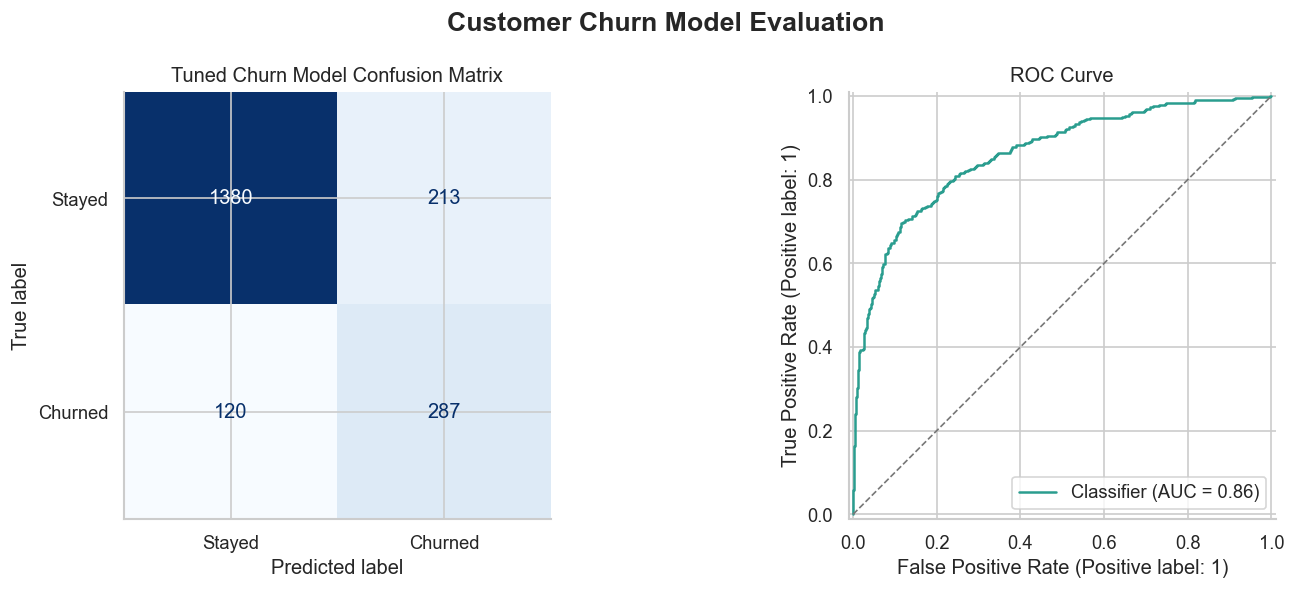

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_pred,
    display_labels=["Stayed", "Churned"],
    cmap="Blues",
    values_format="d",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Tuned Churn Model Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, tuned_proba, ax=axes[1], color="#2A9D8F")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="#777777", linewidth=1)
axes[1].set_title("ROC Curve")

fig.suptitle("Customer Churn Model Evaluation", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task3_model_confusion_and_roc.png", dpi=180, bbox_inches="tight")
plt.show()

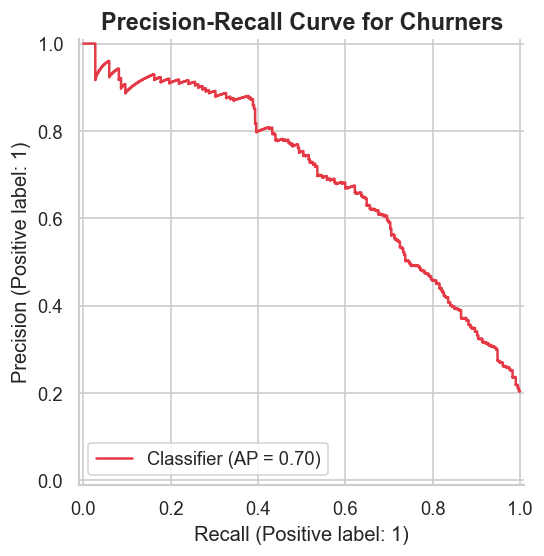

In [18]:
PrecisionRecallDisplay.from_predictions(y_test, tuned_proba, color="#E63946")
plt.title("Precision-Recall Curve for Churners", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task3_precision_recall_curve.png", dpi=180, bbox_inches="tight")
plt.show()

In [19]:
threshold_rows = []
for threshold in np.arange(0.15, 0.61, 0.05):
    threshold_pred = (tuned_proba >= threshold).astype(int)
    threshold_rows.append(
        {
            "threshold": round(threshold, 2),
            "contact_rate": threshold_pred.mean(),
            "precision_churn": precision_score(y_test, threshold_pred, zero_division=0),
            "recall_churn": recall_score(y_test, threshold_pred, zero_division=0),
            "f1_churn": f1_score(y_test, threshold_pred, zero_division=0),
        }
    )

threshold_table = pd.DataFrame(threshold_rows).round(3)
threshold_table

,threshold,contact_rate,precision_churn,recall_churn,f1_churn
0,0.15,0.630,0.304,0.941,0.460
1,0.20,0.538,0.340,0.899,0.493
2,0.25,0.475,0.371,0.865,0.519
3,0.30,0.415,0.410,0.835,0.550
4,0.35,0.362,0.454,0.808,0.582
5,0.40,0.322,0.487,0.771,0.597
6,0.45,0.286,0.523,0.735,0.611
7,0.50,0.250,0.574,0.705,0.633
8,0.55,0.206,0.639,0.649,0.644
9,0.60,0.174,0.678,0.580,0.625


In [20]:
cv_results = cross_validate(
    tuned_model,
    X,
    y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=1,
)

pd.DataFrame(
    {
        metric.replace("test_", ""): [values.mean(), values.std()]
        for metric, values in cv_results.items()
        if metric.startswith("test_")
    },
    index=["mean", "std"],
).round(3)

,accuracy,precision,recall,f1,roc_auc
mean,0.836,0.583,0.677,0.627,0.863
std,0.008,0.018,0.021,0.015,0.006


**Research note:** A retention team would usually prefer high recall when outreach is cheap, because missing churners is expensive. If offers are costly, precision matters more. The threshold table turns the model into a campaign planning tool by showing how many customers would be contacted and how much churn coverage that choice buys.

## Feature Importance and Churn Drivers

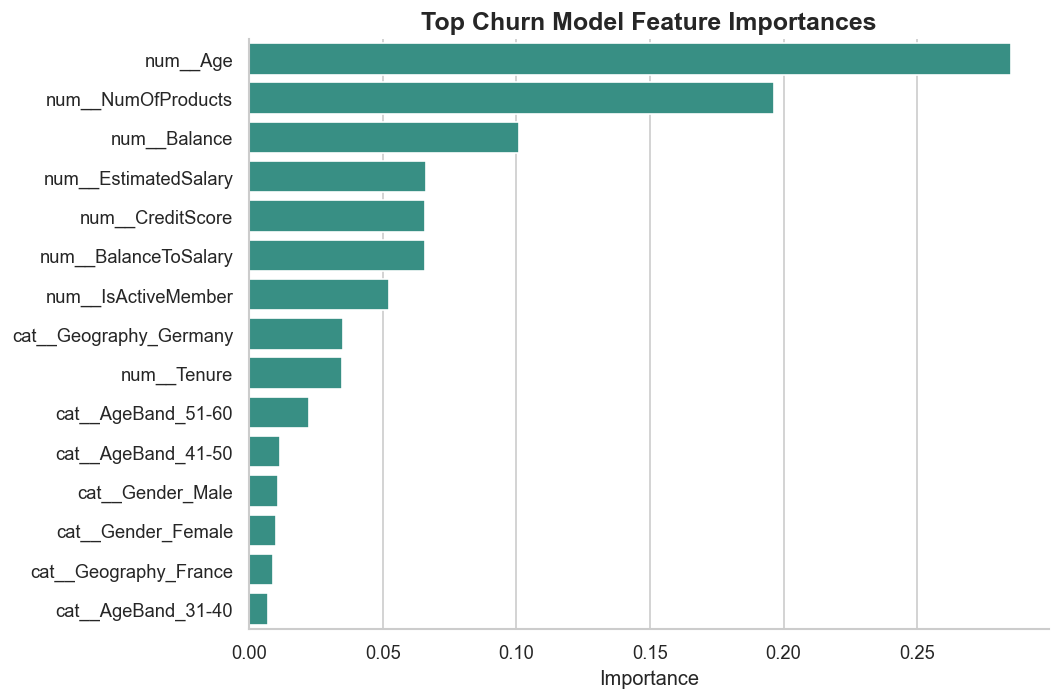

,feature,importance
1,num__Age,0.2850
4,num__NumOfProducts,0.1964
3,num__Balance,0.1010
7,num__EstimatedSalary,0.0661
0,num__CreditScore,0.0660
8,num__BalanceToSalary,0.0658
6,num__IsActiveMember,0.0524
11,cat__Geography_Germany,0.0353
2,num__Tenure,0.0349
18,cat__AgeBand_51-60,0.0224


In [21]:
feature_names = tuned_model.named_steps["preprocess"].get_feature_names_out()
importances = tuned_model.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x="importance", y="feature", color="#2A9D8F")
plt.title("Top Churn Model Feature Importances", fontsize=15, fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task3_feature_importance.png", dpi=180, bbox_inches="tight")
plt.show()

importance_df.round(4)

## Final Findings

1. The dataset is complete and usable after removing identifier fields.
2. Churn is imbalanced: most customers stayed, so accuracy alone is not enough.
3. Age, activity status, product count, balance behavior, and geography show stronger churn relevance than estimated salary.
4. Not all variables explain churn equally. Some fields are useful for profile completeness but weak as churn drivers.
5. VADER sentiment analysis is not applied because there are no review, complaint, or call-note text fields.
6. A random forest is useful for nonlinear churn patterns, while logistic regression remains a transparent baseline. The final model should be used with threshold planning, not as a one-size-fits-all rule.